# Bias Detection in News: Logistic Regression model

## 1. Imports and Setup
Import necessary libraries (pandas, numpy, sklearn, matplotlib, etc.)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

## 2. Data Loading
Load the dataset (`guardian_text.csv`). Display the head and check for missing values.

In [ ]:
df = pd.read_csv("../guardian_text.csv").dropna(subset=["text","label"])

X = df["text"].astype(str)
y = df["label"].astype(str)


## 3. Data Preprocessing
Cleaning, Tokenization, and Vectorization (TF-IDF).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(
    stop_words="english", 
    max_features=5000, 
    ngram_range=(1,2)
    )

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## 4. Model Training and Evaluation
Logistic Regression model training and evaluation

In [5]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_vec, y_train)


y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print("Logistic regression Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic regression Accuracy: 0.9624
Classification Report:
              precision    recall  f1-score   support

      Biased       0.94      0.98      0.96       625
     Neutral       0.98      0.94      0.96       625

    accuracy                           0.96      1250
   macro avg       0.96      0.96      0.96      1250
weighted avg       0.96      0.96      0.96      1250

Confusion Matrix:
[[614  11]
 [ 36 589]]


## 5. ROC Curve, Learning Curve and Confusion Matrix

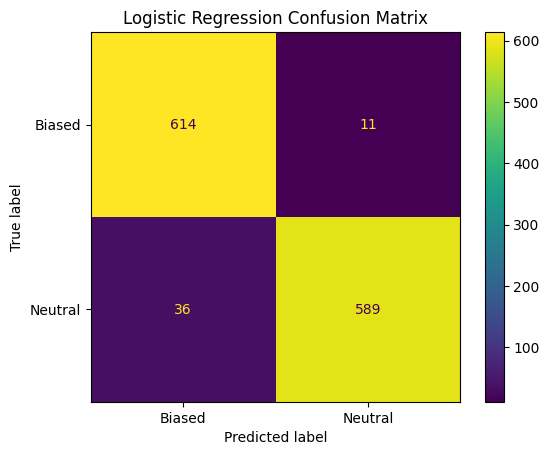

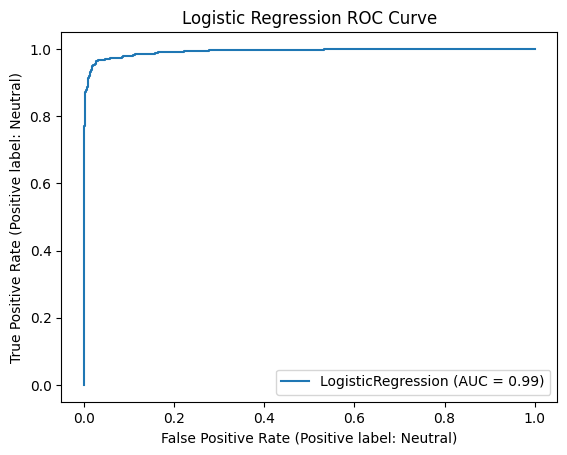

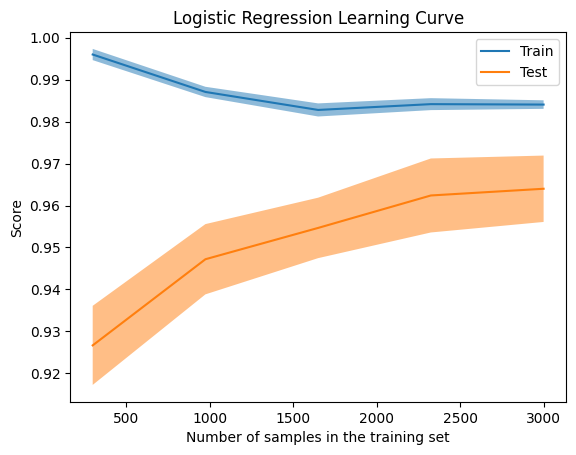

In [6]:

ConfusionMatrixDisplay.from_estimator(model, X_test_vec, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model, X_test_vec, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

LearningCurveDisplay.from_estimator(model, X_train_vec, y_train)
plt.title("Logistic Regression Learning Curve")
plt.show()
